<a href="https://colab.research.google.com/github/pedroroquim-collab/mvp-beer-reviews/blob/main/MVP_PREDI%C3%87%C3%83O_DE_AVALIA%C3%87%C3%83O_DE_CERVEJAS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# MVP de Machine Learning & Analytics
## Análise e Predição de Avaliações de Cervejas utilizando Machine Learning

## 1. Apresentação do Problema

### Contexto
O consumo de cervejas artesanais tem crescido significativamente nos últimos anos, acompanhado pelo aumento de plataformas colaborativas de avaliação, como o **BeerAdvocate**. Essas plataformas permitem que milhares de usuários registrem suas experiências, atribuindo notas para diferentes características sensoriais das cervejas, como aroma, aparência, sabor e sensação na boca (palate), além de uma avaliação geral.

### Objetivo

O objetivo deste trabalho é desenvolver e comparar modelos de Machine Learning capazes de prever a avaliação geral (review_overall) de uma cerveja a partir de suas características sensoriais e do teor alcoólico (beer_abv). Além da construção dos modelos supervisionados, são utilizadas técnicas de análise exploratória e de aprendizado não supervisionado para investigar a estrutura dos dados e identificar possíveis padrões entre as cervejas avaliadas.

### Tipo de Problema

O problema é tratado como uma tarefa de **regressão**, uma vez que a variável de interesse (review_overall) é numérica e assume valores contínuos em uma escala de 0 a 5.

### Hipóteses e limitações

A hipótese deste trabalho é que as características sensoriais avaliadas pelos usuários apresentam forte relação com a nota final atribuída à cerveja, permitindo que modelos de aprendizado de máquina sejam capazes de estimar essa avaliação com boa precisão.

Como limitações deste MVP, destaca-se que o estudo foi desenvolvido a partir de um conjunto de dados históricos disponibilizado pela plataforma BeerAdvocate, estando sujeito à qualidade e à consistência das avaliações registradas pelos usuários. Além disso, a modelagem considera apenas as informações disponíveis no dataset, não contemplando fatores externos que possam influenciar a percepção dos consumidores, como contexto de consumo, perfil dos avaliadores ou condições de degustação.


## 2. Apresentação da Base de Dados

### Dataset utilizado

Neste trabalho foi utilizado o dataset Beer Reviews, disponibilizado publicamente na plataforma Kaggle e composto por avaliações de cervejas extraídas da comunidade BeerAdvocate. A base reúne informações fornecidas por usuários sobre diferentes cervejas, contemplando características sensoriais, informações do produto e a avaliação geral atribuída a cada amostra.

### Fonte dos dados

*   Plataforma: Kaggle
*   Dataset: Beer Reviews(BeerAdvocate)
*   Origem dos dados: BeerAdvocate

### Justificativa da escolha

A escolha desta base de dados foi motivada pela sua dimensão, diversidade de estilos de cerveja e riqueza de atributos relacionados às avaliações dos consumidores. Essas características tornam o conjunto de dados adequado para o desenvolvimento e comparação de diferentes modelos de Machine Learning, além de possibilitar análises exploratórias, modelagem preditiva e técnicas de aprendizado supervisionado e não supervisionado.

### Variável-alvo

A variável escolhida para predição foi **(review_overall)**, que representa a avaliação geral atribuída pelo usuário à cerveja em uma escala de 0 a 5.

### Principais atributos utilizados

O dataset é composto por variáveis numéricas e categóricas que descrevem diferentes aspectos das cervejas avaliadas. Entre os principais atributos utilizados neste trabalho destacam-se:


*  **(review_aroma)** – nota atribuída ao aroma da cerveja;
*  **(review_appearance)** – avaliação da aparência;
*  **(review_palate)** – avaliação da sensação na boca (palate);
*  **(review_taste)** – avaliação do sabor;
*  **(beer_abv)** – teor alcoólico da cerveja.









## 3. Importação das Bibliotecas

Nesta seção são importadas as bibliotecas necessárias para manipulação dos dados, construção dos modelos de Machine Learning, visualização gráfica e avaliação dos resultados. Todas as bibliotecas utilizadas ao longo do projeto são centralizadas nesta etapa para facilitar a reprodutibilidade e a organização do notebook.

In [1]:
# Manipulação de dados
import pandas as pd
import numpy as np

# Visualização
import matplotlib.pyplot as plt

# Divisão dos dados e validação
from sklearn.model_selection import (
    train_test_split,
    KFold,
    cross_val_score,
    GridSearchCV
)

# Pré-processamento
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Modelos de Regressão
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor

# Redução de dimensionalidade e Clusterização
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Métricas de avaliação
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    silhouette_score
)

# Configurações
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 4. Carregamento da Base de Dados

Nesta etapa é realizado o carregamento do dataset utilizado ao longo de todo o projeto. A base de dados original, disponibilizada publicamente na plataforma Kaggle (Beer Reviews — BeerAdvocate), foi compactada em formato gzip e hospedada como release em um repositório público do GitHub. O carregamento é feito diretamente a partir dessa URL pública, garantindo a reprodutibilidade do notebook e permitindo sua execução do início ao fim sem necessidade de configurações adicionais, autenticação ou upload manual de arquivos.

Após o carregamento, serão apresentadas informações iniciais sobre a estrutura do conjunto de dados, servindo como base para a etapa de análise exploratória e para a preparação dos dados utilizada na construção dos modelos de Machine Learning.

In [2]:
# Carregamento do dataset diretamente de URL pública (GitHub Releases)
# O arquivo original (Kaggle/BeerAdvocate, ~180 MB) foi compactado em gzip
# para reduzir o tempo de download; o pandas descompacta automaticamente.

url = "https://github.com/pedroroquim-collab/mvp-beer-reviews/releases/download/v1.0/beer_reviews.csv.gz"

df = pd.read_csv(url, compression="gzip")

print("Dataset carregado com sucesso!")



Dataset carregado com sucesso!


## 5. Conhecimento Inicial da Base de Dados

Antes de iniciar a etapa de preparação dos dados e construção dos modelos de Machine Learning, é fundamental compreender a estrutura do conjunto de dados. Nesta etapa serão analisadas as dimensões da base, as primeiras observações, os tipos das variáveis, estatísticas descritivas e a existência de valores ausentes.

Essa análise inicial permite identificar possíveis inconsistências e compreender as características do dataset, servindo como base para as decisões de pré-processamento realizadas nas etapas seguintes.


In [3]:
# Dimensões da base de dados
print(f"Quantidade de registros: {df.shape[0]:,}")
print(f"Quantidade de atributos: {df.shape[1]}")

Quantidade de registros: 1,586,614
Quantidade de atributos: 13


### Interpretação dos resultados

O dataset é composto por 1.586.614 registros e 13 atributos, caracterizando uma base de grande porte. Essa quantidade de observações contribui para o treinamento de modelos mais robustos e para uma avaliação mais confiável do desempenho dos algoritmos de Machine Learning.


In [4]:
# Visualização das primeiras linhas
df.head()

,brewery_id,brewery_name,review_time,review_overall,review_aroma,review_appearance,review_profilename,beer_style,review_palate,review_taste,beer_name,beer_abv,beer_beerid
0,10325,Vecchio Birraio,1234817823,1.5,2.0,2.5,stcules,Hefeweizen,1.5,1.5,Sausa Weizen,5.0,47986
1,10325,Vecchio Birraio,1235915097,3.0,2.5,3.0,stcules,English Strong Ale,3.0,3.0,Red Moon,6.2,48213
2,10325,Vecchio Birraio,1235916604,3.0,2.5,3.0,stcules,Foreign / Export Stout,3.0,3.0,Black Horse Black Beer,6.5,48215
3,10325,Vecchio Birraio,1234725145,3.0,3.0,3.5,stcules,German Pilsener,2.5,3.0,Sausa Pils,5.0,47969
4,1075,Caldera Brewing Company,1293735206,4.0,4.5,4.0,johnmichaelsen,American Double / Imperial IPA,4.0,4.5,Cauldron DIPA,7.7,64883


### Interpretação dos resultados

A visualização das primeiras observações permite identificar a organização da base e compreender os principais atributos disponíveis. Nesta etapa também é possível verificar a presença da variável-alvo (review_overall) e das variáveis que serão utilizadas posteriormente na modelagem.

In [5]:
# Informações gerais da base
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1586614 entries, 0 to 1586613
Data columns (total 13 columns):
 #   Column              Non-Null Count    Dtype  
---  ------              --------------    -----  
 0   brewery_id          1586614 non-null  int64  
 1   brewery_name        1586599 non-null  object 
 2   review_time         1586614 non-null  int64  
 3   review_overall      1586614 non-null  float64
 4   review_aroma        1586614 non-null  float64
 5   review_appearance   1586614 non-null  float64
 6   review_profilename  1586266 non-null  object 
 7   beer_style          1586614 non-null  object 
 8   review_palate       1586614 non-null  float64
 9   review_taste        1586614 non-null  float64
 10  beer_name           1586614 non-null  object 
 11  beer_abv            1518829 non-null  float64
 12  beer_beerid         1586614 non-null  int64  
dtypes: float64(6), int64(3), object(4)
memory usage: 157.4+ MB


### Interpretação dos resultados

A análise da estrutura da base de dados evidencia que o dataset é composto por **13 atributos**, distribuídos entre variáveis numéricas e categóricas. As variáveis numéricas representam, principalmente, as avaliações sensoriais atribuídas pelos usuários e o teor alcoólico das cervejas, enquanto as variáveis categóricas armazenam informações como o nome da cerveja, o estilo, a cervejaria e o perfil do avaliador.

Observa-se ainda a existência de uma pequena quantidade de valores ausentes nos atributos **brewery_name**, **review_profilename** e **beer_abv**. Esses valores serão tratados na etapa de preparação dos dados, garantindo maior consistência para a construção e avaliação dos modelos de Machine Learning.


In [6]:
# Estatísticas descritivas
df.describe()

,brewery_id,review_time,review_overall,review_aroma,review_appearance,review_palate,review_taste,beer_abv,beer_beerid
count,1.586614e+06,1.586614e+06,1.586614e+06,1.586614e+06,1.586614e+06,1.586614e+06,1.586614e+06,1.518829e+06,1.586614e+06
mean,3.130099e+03,1.224089e+09,3.815581e+00,3.735636e+00,3.841642e+00,3.743701e+00,3.792860e+00,7.042387e+00,2.171279e+04
std,5.578104e+03,7.654427e+07,7.206219e-01,6.976167e-01,6.160928e-01,6.822184e-01,7.319696e-01,2.322526e+00,2.181834e+04
min,1.000000e+00,8.406720e+08,0.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e-02,3.000000e+00
25%,1.430000e+02,1.173224e+09,3.500000e+00,3.500000e+00,3.500000e+00,3.500000e+00,3.500000e+00,5.200000e+00,1.717000e+03
50%,4.290000e+02,1.239203e+09,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.000000e+00,6.500000e+00,1.390600e+04
75%,2.372000e+03,1.288568e+09,4.500000e+00,4.000000e+00,4.000000e+00,4.000000e+00,4.500000e+00,8.500000e+00,3.944100e+04
max,2.800300e+04,1.326285e+09,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.000000e+00,5.770000e+01,7.731700e+04


### Interpretação dos resultados

As estatísticas descritivas permitem compreender o comportamento geral das variáveis numéricas presentes no dataset. Observa-se que a variável **review_overall**, utilizada como alvo deste estudo, apresenta média de aproximadamente **3,82** pontos em uma escala de **0 a 5**, indicando que, em geral, as cervejas avaliadas receberam notas positivas por parte dos usuários.

As avaliações sensoriais (**review_aroma**, **review_appearance**, **review_palate** e **review_taste**) apresentam distribuições semelhantes, com medianas próximas de **4,0**, sugerindo um comportamento consistente entre os diferentes critérios de avaliação. Já o teor alcoólico (**beer_abv**) apresenta maior variabilidade, refletindo a diversidade de estilos de cerveja presentes na base de dados.

De forma geral, as estatísticas indicam que o conjunto de dados possui características adequadas para a aplicação de modelos de Machine Learning, sendo necessária apenas a realização do tratamento dos valores ausentes identificado anteriormente.


In [7]:
# Verificação de valores ausentes
df.isnull().sum()

,0
brewery_id,0
brewery_name,15
review_time,0
review_overall,0
review_aroma,0
review_appearance,0
review_profilename,348
beer_style,0
review_palate,0
review_taste,0


### Interpretação dos resultados

A análise dos valores ausentes demonstra que a maior parte das variáveis do dataset está completa. Apenas três atributos apresentam registros nulos: **brewery_name**, **review_profilename** e **beer_abv**.

Os valores ausentes em **brewery_name** representam uma parcela muito pequena da base de dados e serão removidos durante a etapa de preparação dos dados. Já os valores ausentes em **beer_abv** serão substituídos pela mediana da variável, preservando os registros e reduzindo o impacto de possíveis valores extremos. O atributo **review_profilename** não será utilizado na modelagem e, portanto, seus valores ausentes não interferem no desenvolvimento deste MVP.


## 6. Preparação dos Dados

Após a análise inicial do dataset, foi realizada a etapa de preparação dos dados, com o objetivo de garantir maior consistência para a construção dos modelos de Machine Learning.

Nesta etapa foram executados o tratamento dos valores ausentes, remoção de um pequeno número de registros com informações incompletas, criação de uma amostra representativa da base de dados e definição das variáveis de entrada (features) e da variável-alvo (target).


In [8]:
# Remoção de registros sem identificação da cervejaria
df = df.dropna(subset=['brewery_name'])

print(f"Quantidade de registros após a remoção: {df.shape[0]:,}")

Quantidade de registros após a remoção: 1,586,599


## Interpretação dos resultados

Foram removidos apenas 15 registros, representando uma parcela insignificante da base de dados. Essa remoção não compromete a representatividade do conjunto de dados utilizado neste estudo.

In [9]:
# Tratamento dos valores ausentes do teor alcoólico
df['beer_abv'] = df['beer_abv'].fillna(
    df['beer_abv'].median()
)

print(df['beer_abv'].isnull().sum())

0


## Interpretação dos resultados

Os valores ausentes da variável beer_abv foram substituídos pela mediana da distribuição. A utilização da mediana reduz a influência de valores extremos e preserva todos os registros disponíveis para a modelagem.

In [10]:
# Criação de uma amostra para o desenvolvimento do MVP
df_sample = df.sample(
    n=300000,
    random_state=RANDOM_STATE
)

print(f"Base original: {df.shape[0]:,} registros")
print(f"Base utilizada: {df_sample.shape[0]:,} registros")

Base original: 1,586,599 registros
Base utilizada: 300,000 registros


## Interpretação dos resultados

Embora a base de dados possua mais de 1,5 milhão de registros, foi utilizada uma amostra aleatória de 300.000 avaliações para o desenvolvimento deste MVP. Essa decisão reduz o custo computacional das etapas de treinamento e validação, mantendo um conjunto de dados suficientemente representativo para a construção e comparação dos modelos.

In [11]:
# Variáveis preditoras
features = [
    "review_aroma",
    "review_appearance",
    "review_palate",
    "review_taste",
    "beer_abv"
]

# Variável-alvo
target = "review_overall"

# Separação entre atributos e variável resposta
X = df_sample[features]
y = df_sample[target]

print(f"Número de variáveis preditoras: {len(features)}")
print(f"Variável-alvo: {target}")

Número de variáveis preditoras: 5
Variável-alvo: review_overall


## Interpretação de resultados

Após a preparação da base de dados, foram definidas as variáveis utilizadas na etapa de modelagem. As variáveis review_aroma, review_appearance, review_palate, review_taste e beer_abv foram selecionadas como atributos preditores (features), por representarem características sensoriais e físico-químicas potencialmente relacionadas à percepção de qualidade da cerveja.

A variável review_overall foi definida como variável-alvo (target), representando a nota geral atribuída pelos usuários e constituindo o objetivo da predição realizada pelos modelos de regressão.

##7. Análise Exploratória dos Dados

### Objetivo

Explorar a distribuição das principais variáveis utilizadas na modelagem e compreender o relacionamento entre elas antes do treinamento dos modelos.

##Distribuição da variável-alvo

A primeira etapa da análise exploratória consiste em avaliar a distribuição da variável-alvo (review_overall). Essa análise permite verificar como as avaliações dos usuários estão distribuídas e identificar possíveis concentrações ou assimetrias que possam influenciar o desempenho dos modelos de regressão.

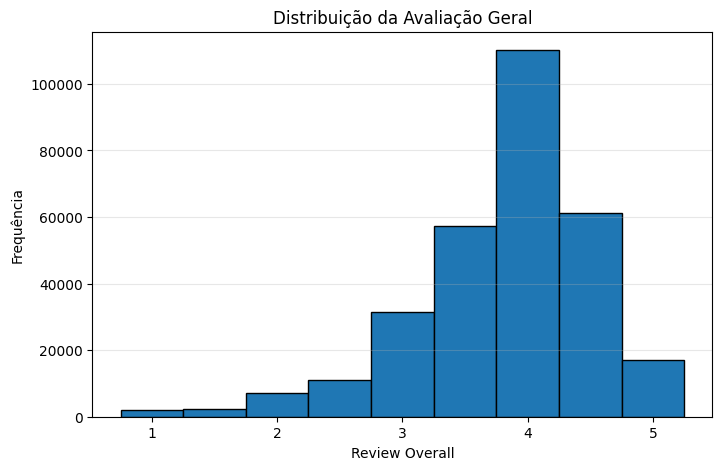

In [12]:
plt.figure(figsize=(8,5))

plt.hist(
    df_sample["review_overall"],
    bins=np.arange(0.75, 5.26, 0.5),
    edgecolor="black"
)

plt.title("Distribuição da Avaliação Geral")
plt.xlabel("Review Overall")
plt.ylabel("Frequência")
plt.grid(axis="y", alpha=0.3)


plt.show()

## Interpretação dos resultados

A distribuição da variável review_overall demonstra uma forte concentração de avaliações entre 3,5 e 4,5 pontos, com pico próximo da nota 4,0. Esse comportamento indica que a maioria das cervejas recebeu avaliações positivas por parte dos usuários da plataforma BeerAdvocate.

Observa-se ainda um número reduzido de avaliações extremamente baixas, sugerindo que notas inferiores a 2,0 representam casos menos frequentes no conjunto de dados. Essa concentração em notas elevadas caracteriza uma distribuição assimétrica, aspecto que deve ser considerado na interpretação do desempenho dos modelos de regressão.

### 7.2 Distribuição do Teor Alcoólico

Além da avaliação geral, o teor alcoólico (`beer_abv`) representa uma das variáveis utilizadas na construção dos modelos de regressão. A análise de sua distribuição permite compreender como essa característica está representada na base de dados, identificando a concentração das observações e a presença de possíveis valores extremos.

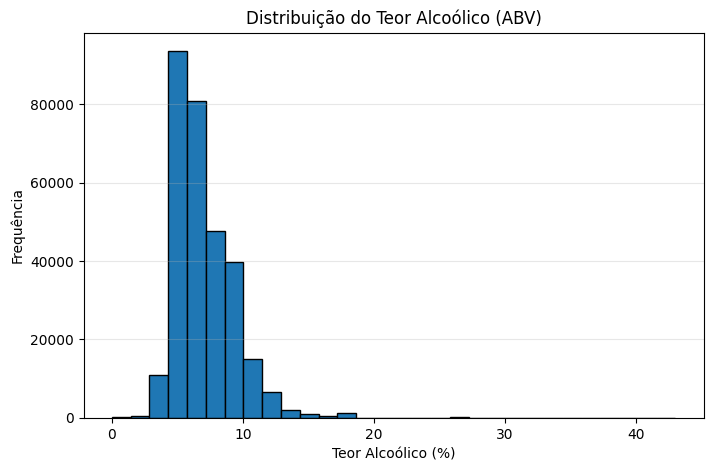

In [13]:
plt.figure(figsize=(8,5))

plt.hist(
    df_sample["beer_abv"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribuição do Teor Alcoólico (ABV)")
plt.xlabel("Teor Alcoólico (%)")
plt.ylabel("Frequência")

plt.grid(axis="y", alpha=0.3)

plt.show()

## Interpretação dos resultados

A distribuição da variável beer_abv apresenta uma concentração significativa de observações entre aproximadamente 4% e 8% de teor alcoólico, faixa correspondente à maioria das cervejas presentes na base de dados. Observa-se ainda uma distribuição assimétrica à direita, caracterizada por uma pequena quantidade de cervejas com elevado teor alcoólico.

A presença desses valores extremos reforça a escolha da mediana para o tratamento dos valores ausentes dessa variável durante a etapa de preparação dos dados, uma vez que essa medida é menos sensível a observações atípicas do que a média. De forma geral, a variabilidade observada indica que o teor alcoólico pode contribuir como atributo preditor na estimativa da avaliação geral das cervejas.

In [14]:
df_sample["beer_abv"].describe()

,beer_abv
count,300000.000000
mean,7.020431
std,2.271635
min,0.010000
25%,5.300000
50%,6.500000
75%,8.400000
max,43.000000


In [15]:
df_sample[features + [target]].corr()

,review_aroma,review_appearance,review_palate,review_taste,beer_abv,review_overall
review_aroma,1.000000,0.559712,0.617316,0.716315,0.325612,0.616058
review_appearance,0.559712,1.000000,0.565357,0.545574,0.258188,0.501299
review_palate,0.617316,0.565357,1.000000,0.734049,0.279752,0.701976
review_taste,0.716315,0.545574,0.734049,1.000000,0.284703,0.790187
beer_abv,0.325612,0.258188,0.279752,0.284703,1.000000,0.134744
review_overall,0.616058,0.501299,0.701976,0.790187,0.134744,1.000000


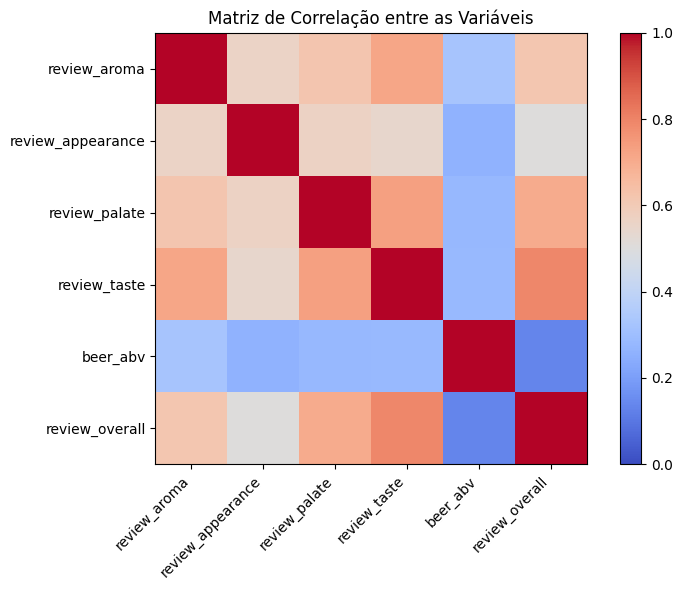

In [16]:
# Matriz de correlação
corr = df_sample[features + [target]].corr()

plt.figure(figsize=(8,6))

im = plt.imshow(corr, cmap="coolwarm", vmin=0, vmax=1)

plt.xticks(
    range(len(corr.columns)),
    corr.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(corr.columns)),
    corr.columns
)

plt.colorbar(im)

plt.title("Matriz de Correlação entre as Variáveis")

plt.tight_layout()

plt.show()

## Interpretação dos resultados

A matriz de correlação evidencia que todas as variáveis sensoriais apresentam correlação positiva com a avaliação geral (review_overall). Entre elas, review_taste apresentou a maior correlação (0,79), seguida por review_palate (0,70) e review_aroma (0,62), indicando que essas características exercem maior influência sobre a nota final atribuída pelos usuários.

Em contrapartida, o teor alcoólico (beer_abv) apresentou correlação positiva, porém bastante reduzida (0,13), sugerindo que essa variável, isoladamente, possui menor capacidade explicativa em relação à percepção geral de qualidade da cerveja.

Esses resultados reforçam a hipótese apresentada no início do trabalho de que as características sensoriais representam os principais fatores associados à avaliação geral, justificando sua utilização como atributos preditores nos modelos de regressão desenvolvidos neste estudo.

## 8. Modelagem Preditiva

Nesta etapa são construídos e avaliados diferentes modelos de Machine Learning com o objetivo de prever a avaliação geral das cervejas (`review_overall`) a partir de suas características sensoriais e do teor alcoólico.

Inicialmente, a base de dados é dividida em conjuntos de treinamento e teste. Em seguida, são treinados diferentes algoritmos de regressão, permitindo comparar seu desempenho por meio de métricas apropriadas e identificar o modelo mais adequado para o problema proposto.

### 8.1 Divisão dos Dados

Para avaliar a capacidade de generalização dos modelos, a base de dados foi dividida em dois subconjuntos:

- **Treinamento (80%)**, utilizado para o aprendizado dos modelos;
- **Teste (20%)**, utilizado exclusivamente para avaliar o desempenho em dados não vistos durante o treinamento.

In [17]:
# Divisão entre treinamento e teste
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print(f"Treinamento: {X_train.shape[0]:,} registros")
print(f"Teste: {X_test.shape[0]:,} registros")

Treinamento: 240,000 registros
Teste: 60,000 registros


In [18]:
# Lista que armazenará os resultados dos modelos
resultados = []

### 8.2 Modelo Baseline

Antes da construção dos modelos de regressão, foi desenvolvido um modelo **Baseline** utilizando o algoritmo `DummyRegressor`. Esse modelo não realiza aprendizado sobre os dados, limitando-se a prever sempre a média da variável-alvo observada no conjunto de treinamento.

O objetivo do Baseline é fornecer um ponto de referência para a avaliação dos demais modelos. Dessa forma, espera-se que os algoritmos de Machine Learning apresentem desempenho superior ao obtido por essa abordagem simples.

In [19]:
from sklearn.dummy import DummyRegressor

# Criação do modelo baseline
baseline = DummyRegressor(strategy="mean")

# Treinamento
baseline.fit(X_train, y_train)

# Previsões
y_pred_baseline = baseline.predict(X_test)

# Avaliação
mae_baseline = mean_absolute_error(y_test, y_pred_baseline)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_pred_baseline))
r2_baseline = r2_score(y_test, y_pred_baseline)

print("=" * 35)
print("Modelo: Baseline")
print("=" * 35)
print(f"MAE : {mae_baseline:.4f}")
print(f"RMSE: {rmse_baseline:.4f}")
print(f"R²  : {r2_baseline:.4f}")

Modelo: Baseline
MAE : 0.5512
RMSE: 0.7197
R²  : -0.0000


In [20]:
resultados.append({
    "Modelo": "Baseline",
    "MAE": mae_baseline,
    "RMSE": rmse_baseline,
    "R²": r2_baseline
})

##Interpretação dos resultados

O modelo Baseline apresentou R² igual a zero, indicando que suas previsões não explicam a variabilidade da variável-alvo. Esse comportamento era esperado, uma vez que o DummyRegressor não aprende padrões presentes nos dados e utiliza apenas a média das avaliações observadas no conjunto de treinamento para realizar todas as previsões.

Dessa forma, o Baseline estabelece um ponto de referência para o estudo, permitindo verificar se os modelos de Machine Learning desenvolvidos nas etapas seguintes conseguem extrair informações relevantes das variáveis preditoras e produzir previsões mais precisas.

### 8.3 Regressão Linear

A Regressão Linear foi utilizada como primeiro modelo de Machine Learning por ser um algoritmo simples, amplamente empregado em problemas de regressão e facilmente interpretável. Esse modelo busca estabelecer uma relação linear entre as variáveis preditoras e a variável-alvo, servindo como referência para comparação com algoritmos mais complexos.

In [21]:
# Criação do modelo
modelo_lr = LinearRegression()

# Treinamento
modelo_lr.fit(X_train, y_train)

# Previsões
y_pred_lr = modelo_lr.predict(X_test)

# Métricas
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("=" * 35)
print("Modelo: Regressão Linear")
print("=" * 35)
print(f"MAE : {mae_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")
print(f"R²  : {r2_lr:.4f}")

Modelo: Regressão Linear
MAE : 0.3080
RMSE: 0.4100
R²  : 0.6754


In [22]:
resultados.append({
    "Modelo": "Regressão Linear",
    "MAE": mae_lr,
    "RMSE": rmse_lr,
    "R²": r2_lr
})

##Interpretação dos resultados

A Regressão Linear apresentou desempenho significativamente superior ao modelo Baseline em todas as métricas avaliadas. O modelo obteve R² de 0,6754, indicando que aproximadamente 67,5% da variabilidade da avaliação geral das cervejas pode ser explicada pelas variáveis utilizadas neste estudo.

Além disso, os baixos valores de MAE (0,3080) e RMSE (0,4100) demonstram que, em média, os erros de predição permaneceram inferiores a meio ponto na escala de avaliação, evidenciando boa capacidade preditiva para o problema analisado.

### 8.4 K-Nearest Neighbors (KNN)

O algoritmo **K-Nearest Neighbors (KNN)** foi utilizado para avaliar uma abordagem baseada em similaridade entre observações. Nesse método, a previsão é realizada considerando as avaliações das **k** cervejas mais semelhantes às características da cerveja analisada. Para esta primeira avaliação foi utilizado o valor padrão de **k = 5**, sendo a otimização desse parâmetro realizada posteriormente.

In [23]:
from sklearn.neighbors import KNeighborsRegressor

# Criação do modelo
modelo_knn = KNeighborsRegressor(
    n_neighbors=5
)

# Treinamento
modelo_knn.fit(X_train, y_train)

# Previsões
y_pred_knn = modelo_knn.predict(X_test)

# Métricas
mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mean_squared_error(y_test, y_pred_knn))
r2_knn = r2_score(y_test, y_pred_knn)

print("=" * 35)
print("Modelo: KNN")
print("=" * 35)
print(f"MAE : {mae_knn:.4f}")
print(f"RMSE: {rmse_knn:.4f}")
print(f"R²  : {r2_knn:.4f}")

Modelo: KNN
MAE : 0.3335
RMSE: 0.4410
R²  : 0.6245


In [24]:
resultados.append({
    "Modelo": "KNN",
    "MAE": mae_knn,
    "RMSE": rmse_knn,
    "R²": r2_knn
})

##Interpretação dos resultados

O modelo K-Nearest Neighbors (KNN) apresentou desempenho superior ao Baseline, demonstrando capacidade de aprender padrões presentes nos dados. Entretanto, seu desempenho foi inferior ao obtido pela Regressão Linear, alcançando R² de 0,6245.

Embora o KNN seja capaz de capturar relações não lineares entre as variáveis, seus resultados sugerem que, para este conjunto de dados, a relação entre as características sensoriais e a avaliação geral é predominantemente linear. Dessa forma, a Regressão Linear mostrou-se mais adequada para representar esse comportamento, apresentando menores erros de predição e maior capacidade explicativa.

### 8.5 Árvore de Decisão

A Árvore de Decisão foi utilizada para avaliar uma abordagem capaz de identificar relações não lineares entre as variáveis preditoras e a variável-alvo. Esse algoritmo realiza sucessivas divisões nos dados, criando regras de decisão que buscam minimizar o erro de predição e capturar padrões mais complexos presentes no conjunto de dados.

In [25]:
from sklearn.tree import DecisionTreeRegressor

modelo_dt = DecisionTreeRegressor(
    random_state=RANDOM_STATE
)

modelo_dt.fit(X_train, y_train)

y_pred_dt = modelo_dt.predict(X_test)

mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
r2_dt = r2_score(y_test, y_pred_dt)

print("=" * 35)
print("Modelo: Árvore de Decisão")
print("=" * 35)
print(f"MAE : {mae_dt:.4f}")
print(f"RMSE: {rmse_dt:.4f}")
print(f"R²  : {r2_dt:.4f}")

Modelo: Árvore de Decisão
MAE : 0.3340
RMSE: 0.4580
R²  : 0.5950


In [26]:
resultados.append({
    "Modelo": "Árvore de Decisão",
    "MAE": mae_dt,
    "RMSE": rmse_dt,
    "R²": r2_dt
})

##Interpretação dos resultados

A Árvore de Decisão apresentou desempenho superior ao modelo Baseline, demonstrando capacidade de aprender padrões presentes nos dados. Entretanto, entre os modelos avaliados até o momento, foi o que apresentou o menor poder preditivo, alcançando R² de 0,5950.

Esse resultado indica que uma única árvore de decisão possui menor capacidade de generalização para este conjunto de dados quando comparada à Regressão Linear e ao KNN. Esse comportamento é esperado, pois árvores individuais tendem a ser mais suscetíveis ao sobreajuste (overfitting), justificando a avaliação de métodos de ensemble, como a Random Forest, na etapa seguinte.

### 8.6 Random Forest

A **Random Forest** é um método de ensemble baseado na construção de múltiplas árvores de decisão. Cada árvore é treinada a partir de diferentes subconjuntos dos dados e das variáveis preditoras, sendo a previsão final obtida pela média das previsões individuais.

Essa abordagem reduz a variância das árvores individuais, melhora a capacidade de generalização do modelo e diminui a ocorrência de sobreajuste, sendo amplamente utilizada em problemas de regressão e classificação.

In [27]:
from sklearn.ensemble import RandomForestRegressor

# Criação do modelo
modelo_rf = RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Treinamento
modelo_rf.fit(X_train, y_train)

# Previsões
y_pred_rf = modelo_rf.predict(X_test)

# Métricas
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("=" * 35)
print("Modelo: Random Forest")
print("=" * 35)
print(f"MAE : {mae_rf:.4f}")
print(f"RMSE: {rmse_rf:.4f}")
print(f"R²  : {r2_rf:.4f}")

Modelo: Random Forest
MAE : 0.3229
RMSE: 0.4292
R²  : 0.6444


In [28]:
resultados.append({
    "Modelo": "Random Forest",
    "MAE": mae_rf,
    "RMSE": rmse_rf,
    "R²": r2_rf
})

##Interpretação dos resultados

A Random Forest apresentou desempenho superior ao KNN e à Árvore de Decisão, alcançando R² de 0,6444. O uso de múltiplas árvores de decisão contribuiu para reduzir a variância do modelo e melhorar sua capacidade de generalização em relação a uma árvore individual.

Apesar desse bom desempenho, a Regressão Linear permaneceu como o modelo com melhor capacidade preditiva, apresentando menores erros de previsão e maior coeficiente de determinação. Esse resultado sugere que a relação entre as características sensoriais avaliadas e a nota geral da cerveja é predominantemente linear, reduzindo a necessidade de modelos mais complexos para representar esse comportamento.

In [29]:
df_resultados = pd.DataFrame(resultados)

df_resultados = df_resultados.sort_values(
    by="R²",
    ascending=False
)

df_resultados = df_resultados.round(4)

df_resultados

,Modelo,MAE,RMSE,R²
1,Regressão Linear,0.3080,0.4100,0.6754
4,Random Forest,0.3229,0.4292,0.6444
2,KNN,0.3335,0.4410,0.6245
3,Árvore de Decisão,0.3340,0.4580,0.5950
0,Baseline,0.5512,0.7197,-0.0000


### 8.7 Comparação dos Modelos

Após o treinamento dos modelos de regressão, os resultados foram consolidados em uma tabela comparativa utilizando as métricas MAE, RMSE e R².

Essa comparação permite identificar qual algoritmo apresentou melhor capacidade preditiva para o problema estudado, considerando simultaneamente o erro médio das previsões e o percentual da variabilidade da variável-alvo explicado pelo modelo.

### Validação Cruzada dos Modelos

Após a avaliação dos modelos no conjunto de teste, foi aplicada a validação cruzada com o objetivo de verificar a estabilidade dos resultados obtidos.

A validação cruzada divide os dados em diferentes subconjuntos, permitindo que cada modelo seja treinado e avaliado em diferentes partes da base. Dessa forma, é possível observar não apenas o desempenho médio, mas também a variação dos resultados entre as diferentes divisões.

In [30]:
models = []

models.append(("Regressão Linear", LinearRegression()))
models.append(("KNN", KNeighborsRegressor(n_neighbors=5)))
models.append(("Árvore de Decisão", DecisionTreeRegressor(random_state=RANDOM_STATE)))
models.append(("Random Forest", RandomForestRegressor(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)))

cv_results_list = []
model_names = []

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

for name, model in models:
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    cv_results = cross_val_score(
        pipeline,
        X,
        y,
        cv=kfold,
        scoring="r2"
    )

    cv_results_list.append(cv_results)
    model_names.append(name)

    print(f"{name}: {cv_results.mean():.4f} ({cv_results.std():.4f})")

Regressão Linear: 0.6740 (0.0013)
KNN: 0.6214 (0.0016)
Árvore de Decisão: 0.5902 (0.0028)
Random Forest: 0.6419 (0.0018)


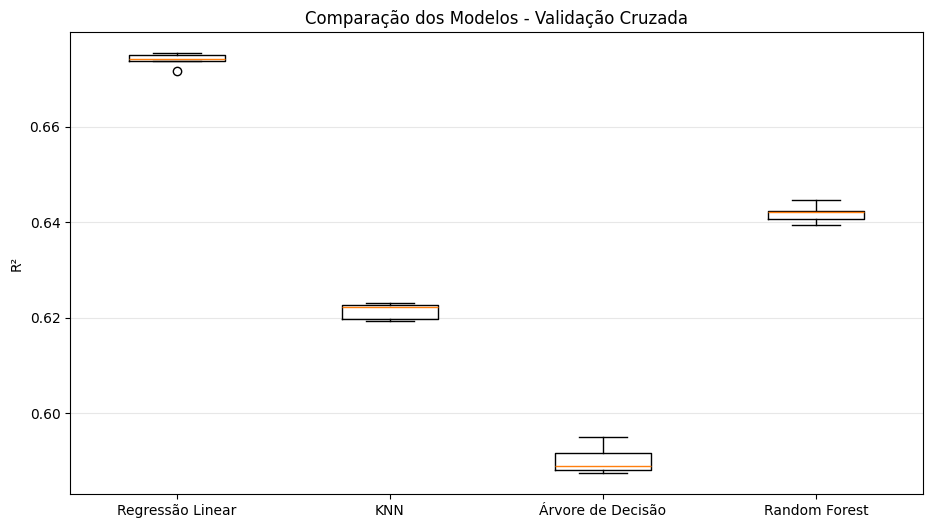

In [31]:
plt.figure(figsize=(11, 6))

plt.boxplot(cv_results_list)

plt.title("Comparação dos Modelos - Validação Cruzada")
plt.ylabel("R²")
plt.xticks(
    range(1, len(model_names) + 1),
    model_names,
    rotation=0
)

plt.grid(axis="y", alpha=0.3)

plt.show()

##Interpretação da Validação Cruzada

A validação cruzada confirmou os resultados obtidos na avaliação realizada sobre o conjunto de teste. A Regressão Linear apresentou o maior R² médio e a menor variabilidade entre os diferentes subconjuntos da base, evidenciando elevada estabilidade e capacidade de generalização.

A Random Forest apresentou desempenho consistente, ocupando a segunda posição, seguida pelo KNN. A Árvore de Decisão apresentou o menor R² médio e maior variabilidade entre os folds, indicando maior sensibilidade às diferentes divisões dos dados.

Até esta etapa, a Regressão Linear apresentou o melhor desempenho e maior estabilidade entre os modelos avaliados. Entretanto, na sequência será realizada a otimização dos hiperparâmetros da Random Forest, verificando se ajustes em sua configuração podem resultar em desempenho superior.

## 8.8 Otimização de Hiperparâmetros da Random Forest

Após a comparação entre os modelos e a validação cruzada, foi realizada uma etapa de otimização dos hiperparâmetros da Random Forest utilizando o algoritmo GridSearchCV. Foram avaliadas combinações dos parâmetros n_estimators e max_depth, buscando identificar a configuração com melhor desempenho médio durante a validação cruzada.

O GridSearchCV automatiza esse processo por meio da validação cruzada, testando todas as combinações especificadas e selecionando aquela que apresenta o melhor desempenho médio. O objetivo dessa etapa é verificar se ajustes na configuração do modelo podem melhorar sua capacidade preditiva.

In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

In [33]:
param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 20, None]
}

In [34]:
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42),
    param_grid=param_grid,
    scoring="r2",
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


GridSearchCV(cv=5, estimator=RandomForestRegressor(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, None],
                         'n_estimators': [100, 200]},
             scoring='r2')

In [35]:
print("Melhores hiperparâmetros:")
print(grid_search.best_params_)

print("\nMelhor R² médio na validação cruzada:")
print(f"{grid_search.best_score_:.4f}")

Melhores hiperparâmetros:
{'max_depth': 10, 'n_estimators': 200}

Melhor R² médio na validação cruzada:
0.6804


In [36]:
best_rf = grid_search.best_estimator_

y_pred_best = best_rf.predict(X_test)

mae_best = mean_absolute_error(y_test, y_pred_best)
rmse_best = np.sqrt(mean_squared_error(y_test, y_pred_best))
r2_best = r2_score(y_test, y_pred_best)

print("="*35)
print("Random Forest Otimizada")
print("="*35)
print(f"MAE : {mae_best:.4f}")
print(f"RMSE: {rmse_best:.4f}")
print(f"R²  : {r2_best:.4f}")

Random Forest Otimizada
MAE : 0.3066
RMSE: 0.4047
R²  : 0.6838


In [37]:
comparacao_rf = pd.DataFrame({
    "Modelo": ["Random Forest", "Random Forest Otimizada"],
    "MAE": [mae_rf, mae_best],
    "RMSE": [rmse_rf, rmse_best],
    "R²": [r2_rf, r2_best]
})

comparacao_rf.round(4)

,Modelo,MAE,RMSE,R²
0,Random Forest,0.3229,0.4292,0.6444
1,Random Forest Otimizada,0.3066,0.4047,0.6838


##Interpretação da Otimização dos Hiperparâmetros

A melhor configuração encontrada foi composta por 200 árvores **(n_estimators = 200)** e profundidade máxima igual a 10 **(max_depth = 10)**, alcançando um R² médio de 0,6804 durante a validação cruzada.

## 8.9 Avaliação do Modelo Otimizado

O modelo obtido após a otimização foi avaliado no conjunto de teste com o objetivo de verificar se a nova configuração proporcionou melhorias em relação à versão original da Random Forest.

Para essa comparação foram utilizadas as mesmas métricas adotadas ao longo deste trabalho: Erro Absoluto Médio (MAE), Raiz do Erro Quadrático Médio (RMSE) e Coeficiente de Determinação (R²).

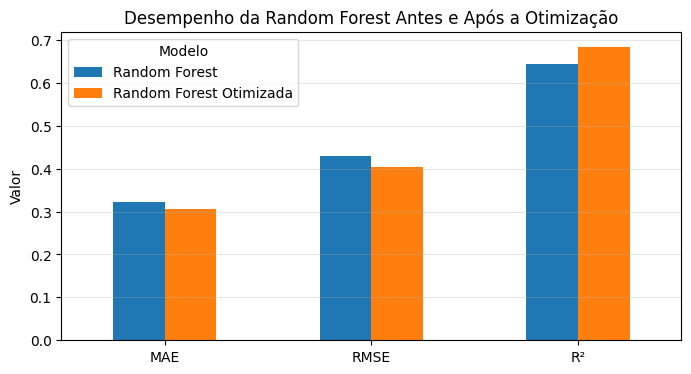

In [38]:
comparacao_plot = comparacao_rf.set_index("Modelo").T

comparacao_plot.plot(
    kind="bar",
    figsize=(8,4)
)

plt.title("Desempenho da Random Forest Antes e Após a Otimização")
plt.ylabel("Valor")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.show()

##Observação
Para as métricas MAE e RMSE, valores menores indicam melhor desempenho. Para o coeficiente de determinação (R²), valores maiores representam melhor capacidade preditiva.

In [39]:
print("R² médio da validação cruzada :", round(grid_search.best_score_, 4))
print("R² no conjunto de teste       :", round(r2_best, 4))

diferenca = abs(grid_search.best_score_ - r2_best)

print("Diferença absoluta            :", round(diferenca, 4))

R² médio da validação cruzada : 0.6804
R² no conjunto de teste       : 0.6838
Diferença absoluta            : 0.0034


### 8.10 Overfitting e Underfitting

### Comparação entre Validação Cruzada e Conjunto de Teste

Após a otimização da Random Forest, foi analisada a capacidade de generalização do modelo por meio da comparação entre o desempenho obtido na validação cruzada e no conjunto de teste, buscando identificar possíveis indícios de overfitting ou underfitting.

O overfitting ocorre quando o modelo aprende excessivamente os padrões específicos do conjunto de treinamento, incluindo ruídos, apresentando excelente desempenho durante o treinamento, mas desempenho inferior em dados não utilizados no treinamento.

Por outro lado, o underfitting ocorre quando o modelo é incapaz de capturar adequadamente os padrões presentes nos dados, resultando em baixo desempenho tanto no treinamento quanto no conjunto de teste.

Neste trabalho, a análise foi realizada comparando o desempenho obtido durante a validação cruzada e a avaliação final no conjunto de teste.

A Random Forest otimizada apresentou R² médio de 0,6804 durante a validação cruzada e R² de 0,6838 no conjunto de teste. A diferença absoluta entre esses resultados foi de apenas 0,0034, indicando elevada estabilidade e boa capacidade de generalização do modelo.

Dessa forma, não foram identificados indícios relevantes de overfitting, uma vez que o desempenho permaneceu consistente entre a validação cruzada e o conjunto de teste. Da mesma forma, os resultados descartam a ocorrência de underfitting, pois o modelo apresentou elevado poder explicativo e baixos erros de predição.

Esses resultados reforçam que a configuração final da Random Forest apresenta bom equilíbrio entre desempenho preditivo e generalização, sendo adequada para a tarefa de previsão da avaliação geral das cervejas.

# 9. Análise por Componentes Principais (PCA)

Após a etapa de modelagem preditiva, foi aplicada a técnica de Análise por Componentes Principais (Principal Component Analysis - PCA), uma abordagem de aprendizado não supervisionado utilizada para reduzir a dimensionalidade do conjunto de dados.

O PCA transforma as variáveis originais em novos componentes ortogonais, preservando a maior parte possível da variabilidade existente nos dados. Essa técnica facilita a visualização da estrutura do conjunto de dados e servirá como base para a etapa de agrupamento utilizando o algoritmo K-Means.

## 9.1 Padronização dos Dados

Como o PCA é baseado na variância das variáveis, foi necessário padronizar os atributos utilizados na modelagem. Para isso foi empregado o StandardScaler, que transforma todas as variáveis para média igual a zero e desvio padrão igual a um, evitando que diferenças de escala influenciem os componentes principais.

In [40]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Formato da base padronizada:", X_scaled.shape)

Formato da base padronizada: (300000, 5)


## 9.2 Aplicação do PCA

Inicialmente o PCA foi aplicado considerando todos os componentes principais disponíveis. Essa etapa permite analisar a contribuição de cada componente para a explicação da variabilidade total dos dados e definir posteriormente quantos componentes serão utilizados na análise.

In [41]:
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

In [42]:
import numpy as np

variancia = pca.explained_variance_ratio_

variancia_df = pd.DataFrame({
    "Componente": np.arange(1, len(variancia) + 1),
    "Variância Explicada": variancia,
    "Variância Acumulada": np.cumsum(variancia)
})

variancia_df

,Componente,Variância Explicada,Variância Acumulada
0,1,0.607492,0.607492
1,2,0.168243,0.775735
2,3,0.101684,0.877419
3,4,0.076138,0.953557
4,5,0.046443,1.000000


##Interpretação dos Dados

A análise da variância explicada mostrou que o primeiro componente principal concentrou aproximadamente 60,7% da variabilidade dos dados. Considerando os dois primeiros componentes principais, foi possível preservar cerca de 77,6% da informação originalmente presente nas cinco variáveis analisadas.

Como esse percentual representa a maior parte da variabilidade do conjunto de dados, optou-se por utilizar dois componentes principais nas etapas seguintes. Essa escolha permite reduzir a dimensionalidade dos dados, facilitar sua visualização em duas dimensões e manter uma quantidade significativa da informação original para a realização da análise de agrupamentos utilizando o algoritmo K-Means.

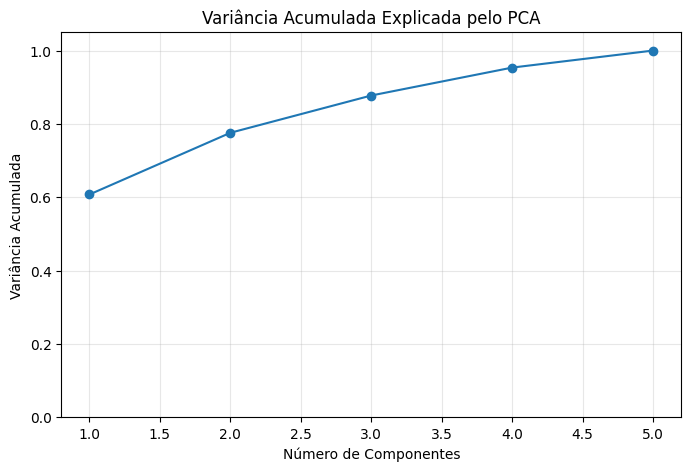

In [43]:
plt.figure(figsize=(8,5))

plt.plot(
    variancia_df["Componente"],
    variancia_df["Variância Acumulada"],
    marker="o"
)

plt.title("Variância Acumulada Explicada pelo PCA")

plt.xlabel("Número de Componentes")

plt.ylabel("Variância Acumulada")

plt.ylim(0,1.05)

plt.grid(alpha=0.3)

plt.show()

In [44]:
pca = PCA(
    n_components=2,
    random_state=42
)

X_pca = pca.fit_transform(X_scaled)

print(X_pca.shape)

(300000, 2)


## 9.3 Visualização dos Componentes Principais

Após a redução da dimensionalidade, os dados foram projetados nos dois primeiros componentes principais. Essa representação permite visualizar a distribuição das observações em um espaço bidimensional preservando aproximadamente 77,6% da variabilidade original do conjunto de dados.

Essa visualização servirá como base para a identificação dos agrupamentos obtidos pelo algoritmo K-Means na etapa seguinte.

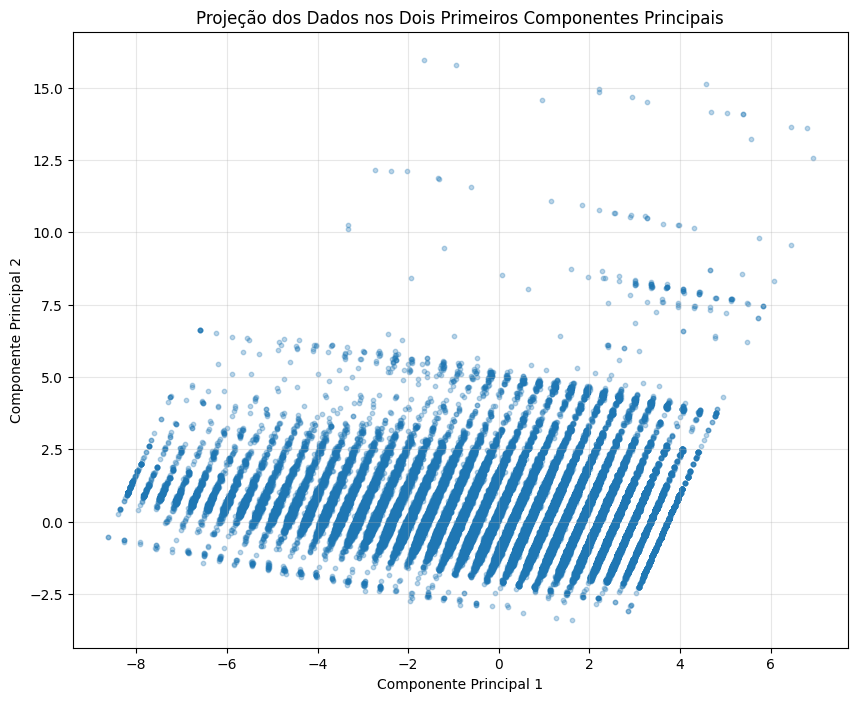

In [45]:
plt.figure(figsize=(10,8))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    alpha=0.3,
    s=10
)

plt.title("Projeção dos Dados nos Dois Primeiros Componentes Principais")

plt.xlabel("Componente Principal 1")

plt.ylabel("Componente Principal 2")

plt.grid(alpha=0.3)

plt.show()

In [46]:
loadings = pd.DataFrame(
    pca.components_.T,
    columns=["PC1", "PC2"],
    index=features
)

loadings

,PC1,PC2
review_aroma,0.489572,-0.066720
review_appearance,0.439602,-0.133691
review_palate,0.489183,-0.170839
review_taste,0.504018,-0.169469
beer_abv,0.271542,0.959046


## Interpretação dos Componentes Principais

A análise das cargas dos componentes principais demonstrou que o Primeiro Componente Principal (PC1) é fortemente influenciado pelas avaliações sensoriais da cerveja, principalmente sabor (review_taste), aroma (review_aroma), paladar (review_palate) e aparência (review_appearance). Dessa forma, esse componente pode ser interpretado como um indicador da qualidade sensorial geral da cerveja.

Por outro lado, o Segundo Componente Principal (PC2) apresentou forte influência da variável beer_abv, indicando que esse componente representa predominantemente o teor alcoólico das cervejas avaliadas, enquanto as variáveis sensoriais apresentaram baixa contribuição para esse componente.

Esses resultados evidenciam que a maior parte da variabilidade dos dados está associada às características sensoriais, enquanto o teor alcoólico constitui uma dimensão praticamente independente, justificando a utilização dos dois primeiros componentes principais para a etapa de agrupamento com o algoritmo K-Means.

# 10. Agrupamento com K-Means

Após a redução da dimensionalidade por meio da Análise por Componentes Principais (PCA), foi aplicada a técnica de agrupamento K-Means, um algoritmo de aprendizado não supervisionado utilizado para identificar grupos de observações semelhantes.

O algoritmo busca particionar os dados em K grupos, minimizando a distância entre cada observação e o centroide do grupo ao qual pertence. Nesta etapa, o objetivo é identificar possíveis perfis de cervejas com características semelhantes, sem utilizar a variável de avaliação geral (review_overall) como referência.

## 10.1 Escolha do Número de Clusters

Antes da aplicação do algoritmo K-Means, foi utilizado o Método do Cotovelo (Elbow Method), que consiste em calcular a soma dos erros quadráticos internos (Inertia) para diferentes quantidades de clusters.

O objetivo é identificar o ponto em que o aumento do número de grupos passa a gerar ganhos marginais na redução do erro, indicando um valor adequado para K.

In [47]:
from sklearn.cluster import KMeans

inercia = []

k_values = range(1, 11)

for k in k_values:

    modelo = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    modelo.fit(X_pca)

    inercia.append(modelo.inertia_)

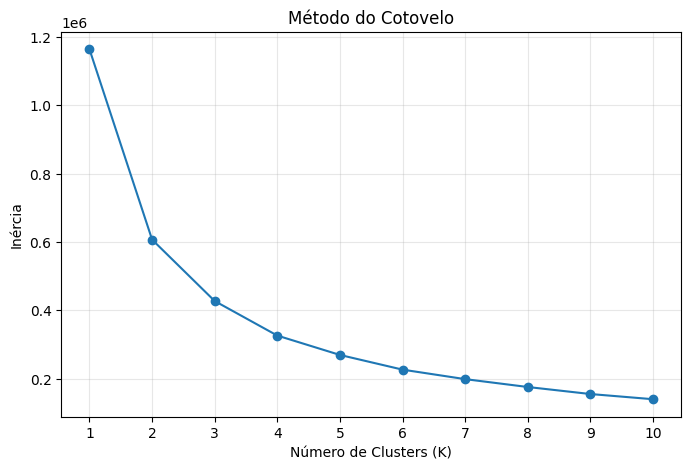

In [48]:
plt.figure(figsize=(8,5))

plt.plot(
    k_values,
    inercia,
    marker="o"
)

plt.title("Método do Cotovelo")

plt.xlabel("Número de Clusters (K)")

plt.ylabel("Inércia")

plt.xticks(k_values)

plt.grid(alpha=0.3)

plt.show()

## Interpretação dos resultados

O Método do Cotovelo foi utilizado para definir a quantidade adequada de clusters para o algoritmo K-Means. Observa-se que a redução da inércia ocorre de forma acentuada entre K = 1 e K = 4. A partir desse ponto, os ganhos obtidos com o aumento do número de clusters tornam-se progressivamente menores, caracterizando o comportamento típico do cotovelo.

Dessa forma, optou-se pela utilização de quatro clusters, buscando um equilíbrio entre a capacidade de representar diferentes perfis de cervejas e a simplicidade do modelo de agrupamento.

In [49]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_pca)

## 10.2 Visualização dos Clusters

Após a definição do número de clusters, o algoritmo K-Means foi aplicado sobre os dois componentes principais obtidos pelo PCA.

Cada observação foi atribuída a um dos quatro grupos identificados pelo algoritmo. A seguir é apresentada a distribuição dos clusters no espaço bidimensional formado pelos componentes principais, permitindo visualizar como as cervejas foram agrupadas de acordo com suas características.

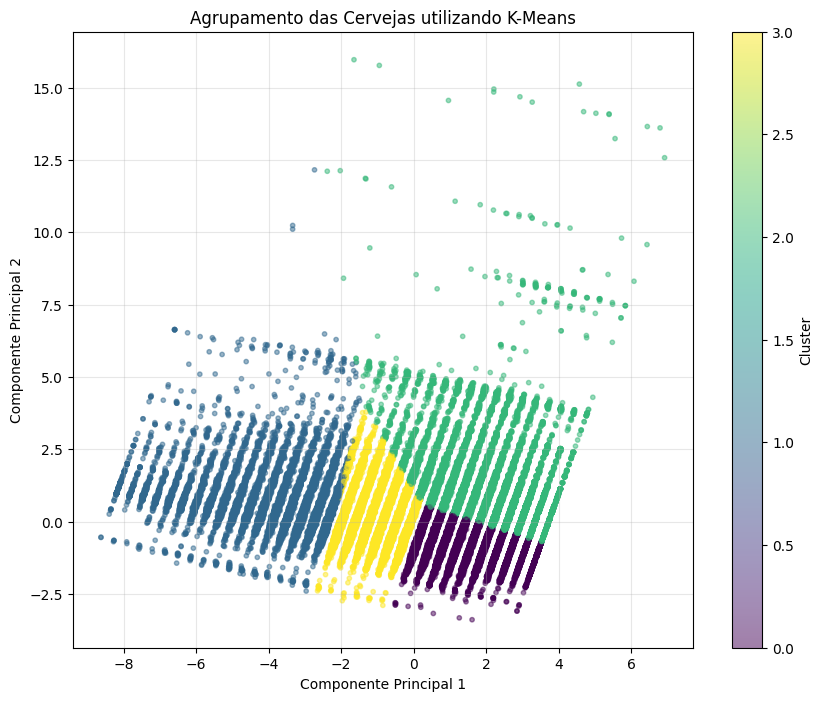

In [50]:
plt.figure(figsize=(10,8))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=clusters,
    cmap="viridis",
    s=10,
    alpha=0.5
)

plt.title("Agrupamento das Cervejas utilizando K-Means")

plt.xlabel("Componente Principal 1")

plt.ylabel("Componente Principal 2")

plt.grid(alpha=0.3)

plt.colorbar(label="Cluster")

plt.show()

In [51]:
df_clusters = df_sample.copy()

df_clusters["Cluster"] = clusters

df_clusters.groupby("Cluster")[features].mean().round(2)

,review_aroma,review_appearance,review_palate,review_taste,beer_abv
Cluster,,,,,
0,4.09,4.13,4.11,4.20,6.23
1,2.50,2.86,2.54,2.42,5.66
2,4.20,4.17,4.16,4.25,10.18
3,3.44,3.63,3.46,3.49,6.14


##Interpretação dos dados

A aplicação do algoritmo K-Means permitiu identificar quatro grupos distintos de cervejas com características semelhantes.

O Cluster 2 apresentou as maiores médias para todas as características sensoriais, além do maior teor alcoólico médio (10,18%), representando cervejas de maior intensidade e melhor avaliação pelos usuários.

O Cluster 0 também reuniu cervejas com avaliações sensoriais elevadas, porém com teor alcoólico moderado, indicando um perfil de cervejas bem avaliadas e mais equilibradas.

O Cluster 3 concentrou cervejas com avaliações intermediárias em todos os atributos analisados, caracterizando um perfil de qualidade mediana.

Já o Cluster 1 apresentou as menores médias para aroma, aparência, paladar e sabor, representando cervejas com menor aceitação pelos consumidores. Observa-se que o teor alcoólico médio desse grupo permaneceu semelhante ao dos clusters intermediários, indicando que o álcool, isoladamente, não explica as avaliações mais baixas.

| Cluster | Perfil                                                 |
| ------- | ------------------------------------------------------ |
| **0**   | Cervejas bem avaliadas com teor alcoólico moderado     |
| **1**   | Cervejas com menor aceitação pelos consumidores        |
| **2**   | Cervejas premium: altas notas e elevado teor alcoólico |
| **3**   | Cervejas de avaliação intermediária                    |


# 11. Avaliação da Qualidade da Clusterização

Além da inspeção visual dos agrupamentos obtidos pelo algoritmo K-Means, foi utilizado o índice de Silhouette para avaliar quantitativamente a qualidade da clusterização.

O Silhouette Score mede simultaneamente a coesão interna dos clusters e a separação entre eles, assumindo valores entre -1 e 1. Valores próximos de 1 indicam grupos bem definidos e separados, enquanto valores próximos de 0 sugerem sobreposição entre clusters.

O índice será calculado primeiro sobre uma amostra de 10.000 observações — procedimento usual para reduzir o custo computacional em bases grandes — e, em seguida, sobre a base completa de 300.000 registros, a fim de validar a representatividade da amostra.

In [52]:
from sklearn.metrics import silhouette_score
import numpy as np

# Amostra de 10.000 observações
rng = np.random.default_rng(RANDOM_STATE)
idx = rng.choice(len(X_pca), size=10000, replace=False)

silhouette = silhouette_score(
    X_pca[idx],
    clusters[idx]
)

print(f"Silhouette Score: {silhouette:.4f}")

Silhouette Score: 0.3638


In [53]:
from sklearn.metrics import silhouette_score

silhouette = silhouette_score(X_pca, clusters)

print(f"Silhouette Score: {silhouette:.4f}")

Silhouette Score: 0.3623


##Interpretação dos resultados

O índice de Silhouette obtido foi de 0,3628, indicando uma qualidade de agrupamento considerada razoável. Esse resultado demonstra que os clusters apresentam boa coesão interna e separação entre si, embora exista alguma sobreposição entre determinados grupos. A análise visual dos clusters confirma esse comportamento, evidenciando regiões bem definidas e outras com transição gradual entre os agrupamentos. Dessa forma, conclui-se que o algoritmo K-Means foi capaz de identificar perfis distintos de cervejas, produzindo uma segmentação consistente para fins exploratórios.

Como validação adicional, o índice também foi calculado utilizando toda a base de 300.000 observações. O valor obtido (0,3623) apresentou diferença mínima em relação ao cálculo realizado sobre a amostra de 10.000 registros (0,3628), indicando que a amostragem foi representativa e que a qualidade da clusterização permaneceu consistente.

# 12. Conclusão

O presente trabalho teve como objetivo desenvolver e comparar modelos de Machine Learning capazes de prever a avaliação geral de cervejas (review_overall) a partir de características sensoriais e do teor alcoólico (beer_abv), utilizando o dataset Beer Reviews, disponibilizado na plataforma Kaggle e composto por aproximadamente 300 mil avaliações provenientes da comunidade BeerAdvocate. Para isso, foram empregadas técnicas de aprendizado supervisionado e não supervisionado, permitindo tanto a construção de modelos preditivos quanto a identificação de padrões entre as cervejas avaliadas.

Na etapa de modelagem preditiva foram avaliados diferentes algoritmos de regressão, incluindo Baseline, Regressão Linear, KNN, Árvore de Decisão e Random Forest. O modelo Baseline foi utilizado como referência inicial, permitindo verificar que todos os modelos de Machine Learning apresentaram desempenho significativamente superior. Entre os algoritmos avaliados inicialmente, a Regressão Linear apresentou o melhor desempenho, alcançando coeficiente de determinação (R²) de 0,6754.

Posteriormente, a Random Forest foi submetida a uma etapa de otimização de hiperparâmetros utilizando o algoritmo GridSearchCV. Após a otimização, o modelo passou a apresentar desempenho superior, atingindo R² de 0,6838 no conjunto de teste, além de reduzir os erros médios de predição (MAE e RMSE), tornando-se o modelo final deste trabalho.

A validação cruzada, aliada à análise de overfitting e underfitting, demonstrou que o modelo apresentou boa capacidade de generalização, mantendo desempenho consistente entre os diferentes subconjuntos dos dados e o conjunto de teste, evidenciando estabilidade e confiabilidade para realizar previsões em dados não utilizados durante o treinamento.

Na etapa de aprendizado não supervisionado, a aplicação da Análise de Componentes Principais (PCA) permitiu reduzir a dimensionalidade dos dados, preservando aproximadamente 77,6% da variabilidade original com apenas dois componentes principais. A análise das cargas dos componentes evidenciou que as avaliações sensoriais exerceram maior influência sobre o primeiro componente, enquanto o teor alcoólico foi responsável pela maior parte da variabilidade do segundo componente.

Em seguida, a aplicação do algoritmo K-Means possibilitou identificar quatro grupos distintos de cervejas com características semelhantes. A qualidade dos agrupamentos foi avaliada por meio do índice de Silhouette, que apresentou valor de 0,3628, indicando uma separação considerada satisfatória entre os clusters para fins exploratórios. Essa etapa demonstrou o potencial das técnicas de aprendizado não supervisionado para identificar perfis de cervejas, complementando a análise preditiva realizada anteriormente.

Como limitações deste estudo, destaca-se que a modelagem foi realizada utilizando apenas as variáveis disponíveis no dataset, não contemplando fatores externos que podem influenciar a percepção dos consumidores, como preferências individuais, contexto de consumo e características específicas de cada estilo de cerveja. Além disso, algumas etapas, como o cálculo do índice de Silhouette utilizando toda a base de dados, apresentaram elevado custo computacional, evidenciando que, para bases de grande porte, a utilização de amostras representativas pode ser uma alternativa eficiente para análises exploratórias.

Como trabalhos futuros, recomenda-se ampliar a avaliação de modelos de regressão, realizar otimizações mais abrangentes dos hiperparâmetros, investigar diferentes técnicas de clusterização e incorporar novas variáveis que possam ampliar a capacidade preditiva dos modelos e enriquecer a análise dos perfis de cervejas.

De forma geral, os resultados demonstraram que as técnicas de Machine Learning empregadas foram capazes de modelar satisfatoriamente o problema proposto, permitindo tanto prever avaliações gerais de cervejas quanto identificar padrões relevantes entre diferentes perfis de produtos. Assim, conclui-se que os objetivos estabelecidos para este MVP foram plenamente alcançados, evidenciando a aplicação integrada de técnicas de aprendizado supervisionado e não supervisionado na solução de um problema real de Ciência de Dados.

# 13. Respostas ao Checklist do MVP

Nesta seção são respondidas, de forma objetiva, as perguntas do checklist sugerido, indicando quando aplicável a seção do notebook em que o tema é tratado em detalhes. Perguntas não aplicáveis ao problema escolhido são indicadas e justificadas.

## Definição do problema

**Qual é a descrição do problema?**
Prever a avaliação geral (`review_overall`) atribuída pelos usuários da plataforma BeerAdvocate a uma cerveja, a partir de suas características sensoriais e do teor alcoólico (Seção 1).

**Qual é o objetivo do modelo?**
Estimar, com o menor erro possível, a nota geral (escala de 0 a 5) de uma cerveja com base nas avaliações de aroma, aparência, paladar, sabor e no teor alcoólico (`beer_abv`).

**O problema é de classificação, regressão, clusterização, previsão de séries temporais ou outro tipo?**
É um problema de **regressão**, pois a variável-alvo é numérica e contínua. De forma complementar, foram aplicadas técnicas não supervisionadas (PCA e K-Means) para explorar a estrutura dos dados (Seções 9 e 10).

**Por que esse problema pode ser resolvido com Machine Learning?**
Porque existe um grande volume de dados históricos rotulados (mais de 1,5 milhão de avaliações) e uma relação mensurável entre os atributos sensoriais e a nota final, permitindo que algoritmos supervisionados aprendam esse padrão e generalizem para novas observações.

**Você tem premissas ou hipóteses sobre o problema? Quais?**
A hipótese central é que as características sensoriais avaliadas pelos usuários possuem forte relação com a nota geral, permitindo predições com boa precisão (Seção 1). Essa hipótese foi confirmada pela matriz de correlação (Seção 7) e pelo desempenho dos modelos.

**Que restrições ou condições foram consideradas na escolha dos dados?**
A base deveria ser pública, acessível por URL (sem login, token ou upload manual), não utilizada nas aulas da sprint, e conter volume e diversidade suficientes para treinar e comparar modelos. O dataset Beer Reviews atende a todos esses critérios.

## Descrição dos dados

**Qual dataset foi utilizado?**
O dataset *Beer Reviews* (BeerAdvocate), com 1.586.614 registros e 13 atributos (Seção 2).

**Qual é a fonte dos dados?**
O dataset foi disponibilizado publicamente na plataforma Kaggle, com origem nas avaliações da comunidade BeerAdvocate.

**Como os dados foram carregados no notebook?**
Diretamente a partir de uma URL pública, via `pd.read_csv()`, garantindo a execução do notebook do início ao fim sem configuração manual (Seção 4).

**Quantos registros e atributos existem?**
1.586.614 registros e 13 atributos. Para reduzir o custo computacional, foi utilizada uma amostra aleatória de 300.000 registros (Seção 6).

**Quais são os principais atributos?**
`review_aroma`, `review_appearance`, `review_palate`, `review_taste` (avaliações sensoriais) e `beer_abv` (teor alcoólico), utilizados como variáveis preditoras (Seção 2).

**Existe variável-alvo? Se sim, qual?**
Sim: `review_overall`, a avaliação geral atribuída pelo usuário, em escala de 0 a 5.

**Há limitações conhecidas no dataset?**
Sim: os dados dependem da qualidade e consistência das avaliações subjetivas dos usuários e não contemplam fatores externos como contexto de consumo, perfil dos avaliadores ou condições de degustação (Seções 1 e 12).

## Preparação dos dados

**Houve valores ausentes? Como foram tratados?**
Sim, em `brewery_name`, `review_profilename` e `beer_abv`. Os 15 registros sem `brewery_name` foram removidos (parcela insignificante); os ausentes de `beer_abv` foram imputados com a mediana, medida menos sensível aos valores extremos observados na distribuição; `review_profilename` não foi utilizado na modelagem (Seções 5 e 6).

**Houve necessidade de remover ou transformar atributos?**
Sim. Atributos identificadores e categóricos de alta cardinalidade (nome da cerveja, cervejaria, perfil do avaliador, estilo) não foram utilizados na modelagem, por não contribuírem diretamente para o objetivo preditivo definido.

**Foram criados novos atributos?**
Não. As variáveis originais do dataset já representavam adequadamente as características sensoriais e físico-químicas de interesse, não havendo necessidade de engenharia de atributos adicional neste MVP.

**Foram aplicadas normalização, padronização, codificação ou outras transformações?**
Sim. Foi aplicada padronização com `StandardScaler`, dentro de `Pipeline`, na validação cruzada dos modelos e na etapa de PCA/K-Means, evitando que diferenças de escala influenciem algoritmos sensíveis a distância (Seções 8.7 e 9.1). Não houve necessidade de codificação de variáveis categóricas, pois apenas atributos numéricos foram utilizados.

**Houve preocupação com vazamento de dados?**
Sim. O conjunto de teste foi utilizado exclusivamente para a avaliação final, e a otimização de hiperparâmetros foi realizada com validação cruzada apenas sobre os dados de treino. Na validação cruzada, a padronização foi encapsulada em `Pipeline`, sendo ajustada apenas nos folds de treino. Como limitação reconhecida, a imputação da mediana de `beer_abv` foi calculada sobre a base completa antes da divisão; dado o volume de dados (mais de 1,5 milhão de registros), o impacto dessa escolha sobre o valor da mediana é desprezível.

**As transformações foram aplicadas de forma adequada à divisão treino/teste?**
Sim, conforme descrito acima: o uso de `Pipeline` garante que o ajuste das transformações ocorra apenas nos dados de treinamento de cada fold, e o conjunto de teste permaneceu isolado até a avaliação final.

## Divisão dos dados

**Como os dados foram separados?**
Divisão aleatória em treinamento (80%) e teste (20%), com semente fixa (`random_state = 42`) para garantir reprodutibilidade (Seção 8.1).

**Foi usada divisão treino/teste?**
Sim, na proporção 80/20.

**Foi usada validação ou validação cruzada?**
Sim. Foi aplicada validação cruzada K-Fold (k = 5) para comparar a estabilidade dos modelos (Seção 8.7) e também dentro do `GridSearchCV` na otimização de hiperparâmetros (Seção 8.8).

**A estratégia de divisão é adequada para o tipo de problema?**
Sim. As observações são independentes entre si, sem estrutura temporal relevante para o objetivo, tornando a divisão aleatória com validação cruzada adequada para um problema de regressão tabular.

**No caso de séries temporais, a ordem temporal foi respeitada?**
Não se aplica: o problema não foi tratado como série temporal, pois o objetivo é prever a nota a partir de atributos da avaliação, e não modelar a evolução das notas ao longo do tempo.

**No caso de clusterização, como a avaliação foi planejada?**
A clusterização (K-Means) foi avaliada por três vias complementares: o Método do Cotovelo para a escolha do número de clusters, o índice de Silhouette para medir quantitativamente coesão e separação dos grupos, e a análise visual e interpretativa dos perfis médios de cada cluster (Seções 10 e 11).

## Modelagem

**Qual foi o baseline utilizado?**
Um `DummyRegressor` com estratégia de média, que prevê sempre a média da variável-alvo do treino, servindo como referência mínima de desempenho (Seção 8.2).

**Quais modelos foram treinados?**
Regressão Linear, K-Nearest Neighbors (KNN), Árvore de Decisão e Random Forest, além do baseline (Seções 8.3 a 8.6).

**Por que esses modelos foram escolhidos?**
Para cobrir abordagens complementares: um modelo linear simples e interpretável (Regressão Linear), um método baseado em similaridade (KNN), um método capaz de capturar relações não lineares (Árvore de Decisão) e um ensemble que reduz a variância das árvores individuais (Random Forest).

**Os modelos foram comparados de forma justa?**
Sim: todos foram treinados e avaliados sobre a mesma divisão treino/teste, com as mesmas métricas (MAE, RMSE, R²), e posteriormente comparados via validação cruzada com o mesmo esquema de folds e semente fixa.

**Foi observado algum indício de underfitting?**
Não. Todos os modelos superaram amplamente o baseline, e o modelo final apresentou R² de aproximadamente 0,68, com erros médios inferiores a meio ponto na escala de avaliação, indicando que os padrões relevantes dos dados foram capturados (Seção 8.10).

**Algum modelo apresentou sinais de overfitting?**
A Árvore de Decisão isolada apresentou o menor desempenho e a maior variabilidade entre os folds, comportamento coerente com sua conhecida tendência ao sobreajuste. No modelo final (Random Forest otimizada), a diferença entre o R² da validação cruzada (0,6804) e o do teste (0,6838) foi de apenas 0,0034, indicando ausência de overfitting relevante (Seção 8.10).

## Otimização

**Algum modelo teve hiperparâmetros ajustados?**
Sim, a Random Forest (Seção 8.8).

**Quais hiperparâmetros foram escolhidos?**
`n_estimators` (100 e 200) e `max_depth` (10, 20 e None), por serem os parâmetros com maior influência sobre a capacidade do ensemble e sobre o equilíbrio entre ajuste e generalização.

**Qual estratégia de busca foi usada?**
Grid Search (`GridSearchCV`) com validação cruzada de 5 folds e R² como critério de seleção.

**O ajuste trouxe melhora em relação à versão inicial?**
Sim. A Random Forest otimizada (n_estimators = 200, max_depth = 10) atingiu R² de 0,6838 no teste, superando a versão inicial (R² = 0,6444) e também a Regressão Linear (R² = 0,6754), tornando-se o modelo final do trabalho.

**A otimização foi feita sem usar indevidamente os dados de teste?**
Sim. O `GridSearchCV` foi ajustado exclusivamente sobre o conjunto de treinamento, com seleção da melhor configuração via validação cruzada interna; o conjunto de teste foi utilizado apenas na avaliação final do modelo escolhido.

## Avaliação

**Quais métricas foram utilizadas?**
MAE, RMSE e R² para a regressão; índice de Silhouette para a clusterização.

**Por que essas métricas são adequadas?**
O MAE expressa o erro médio na própria escala da nota (fácil interpretação); o RMSE penaliza erros maiores; o R² indica o percentual da variabilidade da variável-alvo explicado pelo modelo. Em conjunto, oferecem uma visão complementar de erro e poder explicativo. O Silhouette avalia simultaneamente coesão e separação dos clusters, adequado quando não há variável-alvo de referência.

**Qual modelo teve melhor desempenho?**
A Random Forest otimizada, com MAE ≈ 0,30, RMSE ≈ 0,40 e R² = 0,6838 no conjunto de teste.

**Os resultados fazem sentido para o problema?**
Sim. As variáveis sensoriais — especialmente `review_taste`, com correlação de 0,79 com a nota geral — explicam a maior parte da avaliação, o que é coerente com a intuição de que o sabor domina a percepção de qualidade de uma cerveja. O teor alcoólico, com correlação baixa (0,13), teve papel secundário, também condizente com o esperado.

**Houve análise de erros?**
Sim, por meio da comparação das métricas de erro (MAE e RMSE) entre modelos, da análise da variabilidade dos resultados entre os folds da validação cruzada (boxplot da Seção 8.7) e da comparação entre desempenho em validação cruzada e teste (Seção 8.10). Como oportunidade de aprofundamento futuro, poderia ser realizada uma análise de resíduos por faixa de nota.

**Quais são as principais limitações da solução?**
A modelagem utiliza apenas as variáveis do dataset, sem contemplar fatores externos (contexto de consumo, perfil do avaliador, estilo da cerveja); as variáveis preditoras são notas atribuídas pelo mesmo avaliador na mesma revisão, o que naturalmente eleva a correlação com a nota geral; e o custo computacional de algumas etapas exigiu o uso de amostragem (Seções 1 e 12).

## Conclusão

**Qual foi a melhor solução encontrada?**
A Random Forest com hiperparâmetros otimizados via GridSearchCV (n_estimators = 200, max_depth = 10), com R² de 0,6838 no conjunto de teste.

**Por que ela foi escolhida?**
Por apresentar, após a otimização, o melhor desempenho em todas as métricas avaliadas, com diferença mínima entre validação cruzada e teste, evidenciando boa capacidade de generalização e estabilidade.

**O MVP cumpriu o objetivo definido no início?**
Sim. Os modelos superaram amplamente o baseline e confirmaram a hipótese de que as características sensoriais explicam a maior parte da avaliação geral. A etapa não supervisionada complementou a análise, identificando quatro perfis distintos de cervejas.

**Quais seriam os próximos passos para melhorar o projeto?**
Avaliar modelos adicionais (como Gradient Boosting), realizar otimizações mais abrangentes de hiperparâmetros, incorporar novas variáveis (como o estilo da cerveja, via codificação adequada), investigar outras técnicas de clusterização e realizar análise de resíduos detalhada (Seção 12).